# 01 — Data availability check: Gaza province, Mozambique

Goal: before building the full pipeline, confirm that SMAP soil moisture, CHIRPS precipitation,
Sentinel-2 NDVI, and Sentinel-1 backscatter actually have usable coverage over Gaza for a period
that includes a known drought (e.g. 2023-2024), and that a drought signal is visible in the raw
series.

Requires the project venv (`../.venv`, registered as Jupyter kernel `mz-drought-venv`) and a
prior `earthengine authenticate`.

In [1]:
import sys
sys.path.append("../src")

import ee
import matplotlib.pyplot as plt

import gee_extract as gx

ee.Initialize(project="geoprocessamento-426809")

In [2]:
START = "2023-01-01"
END = "2024-12-31"
AOI = gx.gaza_aoi()

## SMAP surface soil moisture

3-hourly cadence over a 2-year range — fetched in monthly chunks internally (a single request
over the full range hits Earth Engine's memory limit), so this cell takes a couple of minutes.

In [3]:
smap_df = gx.region_time_series(
    gx.COLLECTIONS["smap_soil_moisture"], "sm_surface", AOI, START, END, scale=10000
)
print(smap_df.shape)
smap_df.head()

(5840, 2)


,date,sm_surface
0,2023-01-01,0.090261
1,2023-01-01,0.090991
2,2023-01-01,0.090191
3,2023-01-01,0.089198
4,2023-01-01,0.088615


## CHIRPS daily precipitation

In [4]:
chirps_df = gx.region_time_series(
    gx.COLLECTIONS["chirps_precip"], "precipitation", AOI, START, END, scale=5000
)
print(chirps_df.shape)
chirps_df.head()

(730, 2)


,date,precipitation
0,2023-01-01,0.015695
1,2023-01-02,0.375826
2,2023-01-03,0.000000
3,2023-01-04,0.083008
4,2023-01-05,16.723365


## Sentinel-2 NDVI (10 m native, reduced at 100 m for a province-sized AOI)

In [5]:
ndvi_df = gx.sentinel2_ndvi_time_series(AOI, START, END, scale=100, max_cloud_pct=40)
print(ndvi_df.shape)
ndvi_df.head()

(2099, 2)


,NDVI,date
0,0.560427,2023-01-03
1,0.409227,2023-01-03
2,0.580543,2023-01-03
3,0.506699,2023-01-03
4,0.661245,2023-01-03


## Sentinel-1 VV backscatter

In [6]:
s1_df = gx.sentinel1_vv_time_series(AOI, START, END, scale=100)
print(s1_df.shape)
s1_df.head()

(827, 2)


,VV,date
0,-11.802830,2023-01-01
1,-10.894044,2023-01-01
2,-10.665575,2023-01-03
3,-10.679290,2023-01-03
4,-10.388379,2023-01-03


## Plot all four series to eyeball coverage gaps and drought signal

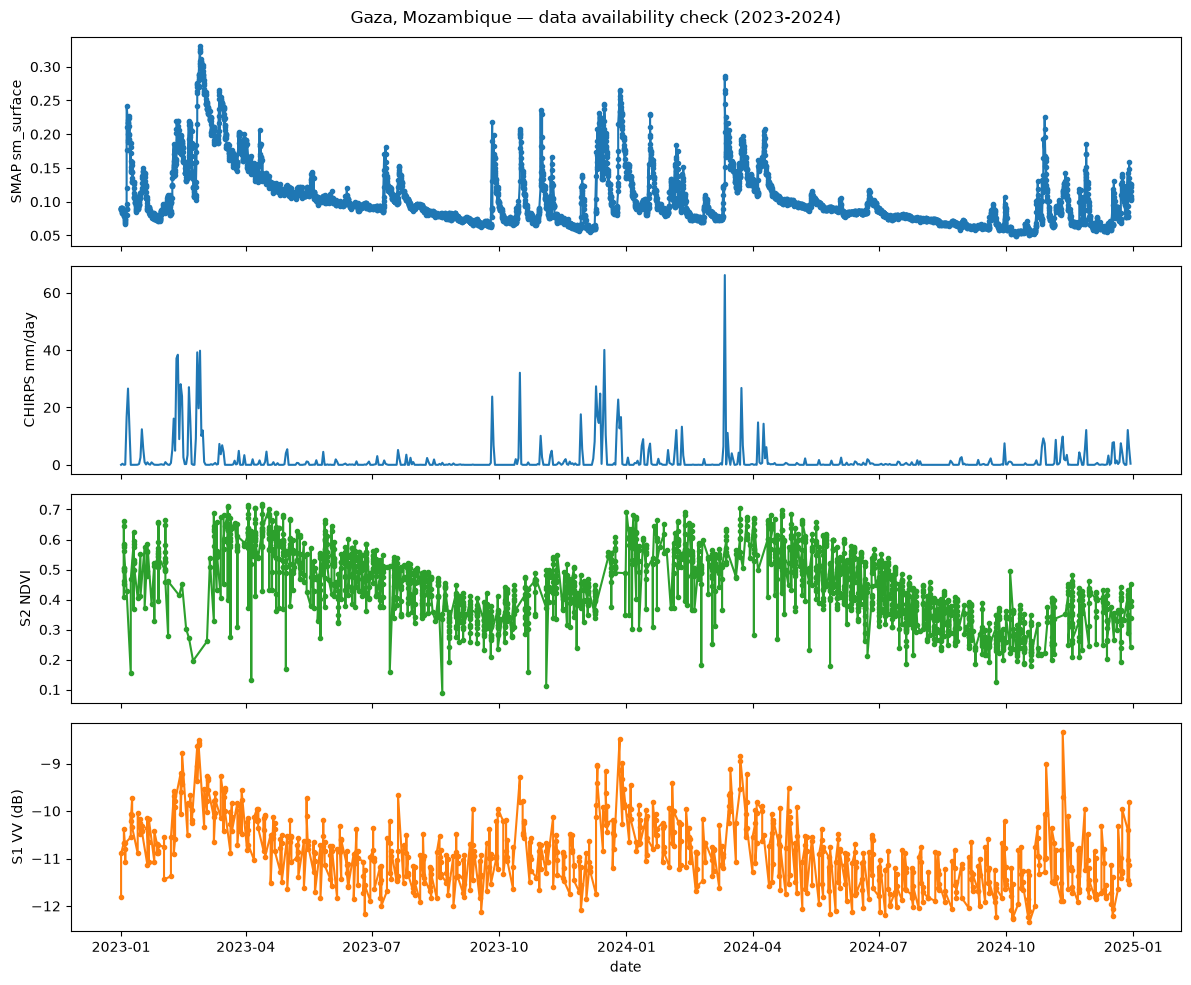

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(smap_df["date"], smap_df["sm_surface"], marker=".")
axes[0].set_ylabel("SMAP sm_surface")

axes[1].plot(chirps_df["date"], chirps_df["precipitation"], color="tab:blue")
axes[1].set_ylabel("CHIRPS mm/day")

axes[2].plot(ndvi_df["date"], ndvi_df["NDVI"], marker=".", color="tab:green")
axes[2].set_ylabel("S2 NDVI")

axes[3].plot(s1_df["date"], s1_df["VV"], marker=".", color="tab:orange")
axes[3].set_ylabel("S1 VV (dB)")
axes[3].set_xlabel("date")

fig.suptitle("Gaza, Mozambique — data availability check (2023-2024)")
fig.tight_layout()
plt.show()

## Checklist before moving to the full pipeline

- [x] SMAP series has no large gaps over the study period — 5840/5840 expected 3-hourly steps present, dense coverage throughout
- [x] CHIRPS shows a clear wet/dry seasonal cycle — 730/730 days, clean Nov-Mar wet season peaks each year
- [x] Sentinel-2 NDVI has enough cloud-free observations (2099 obs over 2 years) — visible seasonal greening/senescence cycle, no long blank stretches
- [x] Sentinel-1 has enough revisits (827 obs over 2 years) — consistent coverage, wet/dry backscatter contrast visible
- [x] Interannual drought signal is visible: 2024's dry-season SMAP minimum (~0.05) sits below 2023's (~0.07), and the Nov 2023-Apr 2024 wet season shows a lower, more erratic soil moisture response than 2022-2023 despite an intense isolated CHIRPS rain spike — consistent with the known 2023-2024 southern Africa El Niño drought reaching Gaza province

**Conclusion: data availability confirmed. Safe to move on to the feature engineering / model pipeline stage.**